In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input/datasets/abdelazizel7or/airline-delay-cause/Airline_Delay_Cause.csv'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sb
import matplotlib.pyplot as plt
from matplotlib import rcParams
from scipy.stats import norm
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from scipy import stats
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

sb.set()
sb.set_style("white")
%matplotlib inline
rcParams['figure.figsize'] = [10,7]

In [3]:
data = pd.read_csv("data/Airline_Delay_Cause-selected-columns.csv")
data.head()

,year,month,carrier,carrier_name,airport,airport_name,arr_flights,arr_del15,carrier_ct,weather_ct
0,2022,5,9E,Endeavor Air Inc.,ABE,"Allentown/Bethlehem/Easton, PA: Lehigh Valley ...",136.0,7.0,5.95,0.00
1,2022,5,9E,Endeavor Air Inc.,ABY,"Albany, GA: Southwest Georgia Regional",91.0,16.0,7.38,0.00
2,2022,5,9E,Endeavor Air Inc.,ACK,"Nantucket, MA: Nantucket Memorial",19.0,2.0,0.13,0.00
3,2022,5,9E,Endeavor Air Inc.,AEX,"Alexandria, LA: Alexandria International",88.0,14.0,7.26,0.76
4,2022,5,9E,Endeavor Air Inc.,AGS,"Augusta, GA: Augusta Regional at Bush Field",181.0,19.0,13.84,0.00


In [4]:
data.columns

Index(['year', 'month', 'carrier', 'carrier_name', 'airport', 'airport_name',
       'arr_flights', 'arr_del15', 'carrier_ct', 'weather_ct'],
      dtype='str')

In [5]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 318017 entries, 0 to 318016
Data columns (total 10 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   year          318017 non-null  int64  
 1   month         318017 non-null  int64  
 2   carrier       318013 non-null  str    
 3   carrier_name  318013 non-null  str    
 4   airport       318014 non-null  str    
 5   airport_name  318017 non-null  str    
 6   arr_flights   317524 non-null  float64
 7   arr_del15     317285 non-null  float64
 8   carrier_ct    317525 non-null  float64
 9   weather_ct    317523 non-null  float64
dtypes: float64(4), int64(2), str(4)
memory usage: 24.3 MB


In [6]:
print((data.shape),'\n')
print("Shape of Airline_Delay_Cause.csv: ", data.shape)

(318017, 10) 

Shape of Airline_Delay_Cause.csv:  (318017, 10)


In [7]:
missing_values = data.isnull().sum()
display(missing_values[missing_values>0].sort_values(ascending=False).to_frame(name='Missing Values'))

,Missing Values
arr_del15,732
weather_ct,494
arr_flights,493
carrier_ct,492
carrier,4
carrier_name,4
airport,3


In [8]:
num_cols = data.select_dtypes(include=np.number).columns
data[num_cols] = data[num_cols].fillna(data[num_cols].median())

cat_cols = data.select_dtypes(include='object').columns
data[cat_cols] = data[cat_cols].fillna(data[cat_cols].mode().iloc[0])

In [9]:
data.isnull().sum()

year            0
month           0
carrier         0
carrier_name    0
airport         0
airport_name    0
arr_flights     0
arr_del15       0
carrier_ct      0
weather_ct      0
dtype: int64

In [10]:
duplicates = data[data.duplicated()]

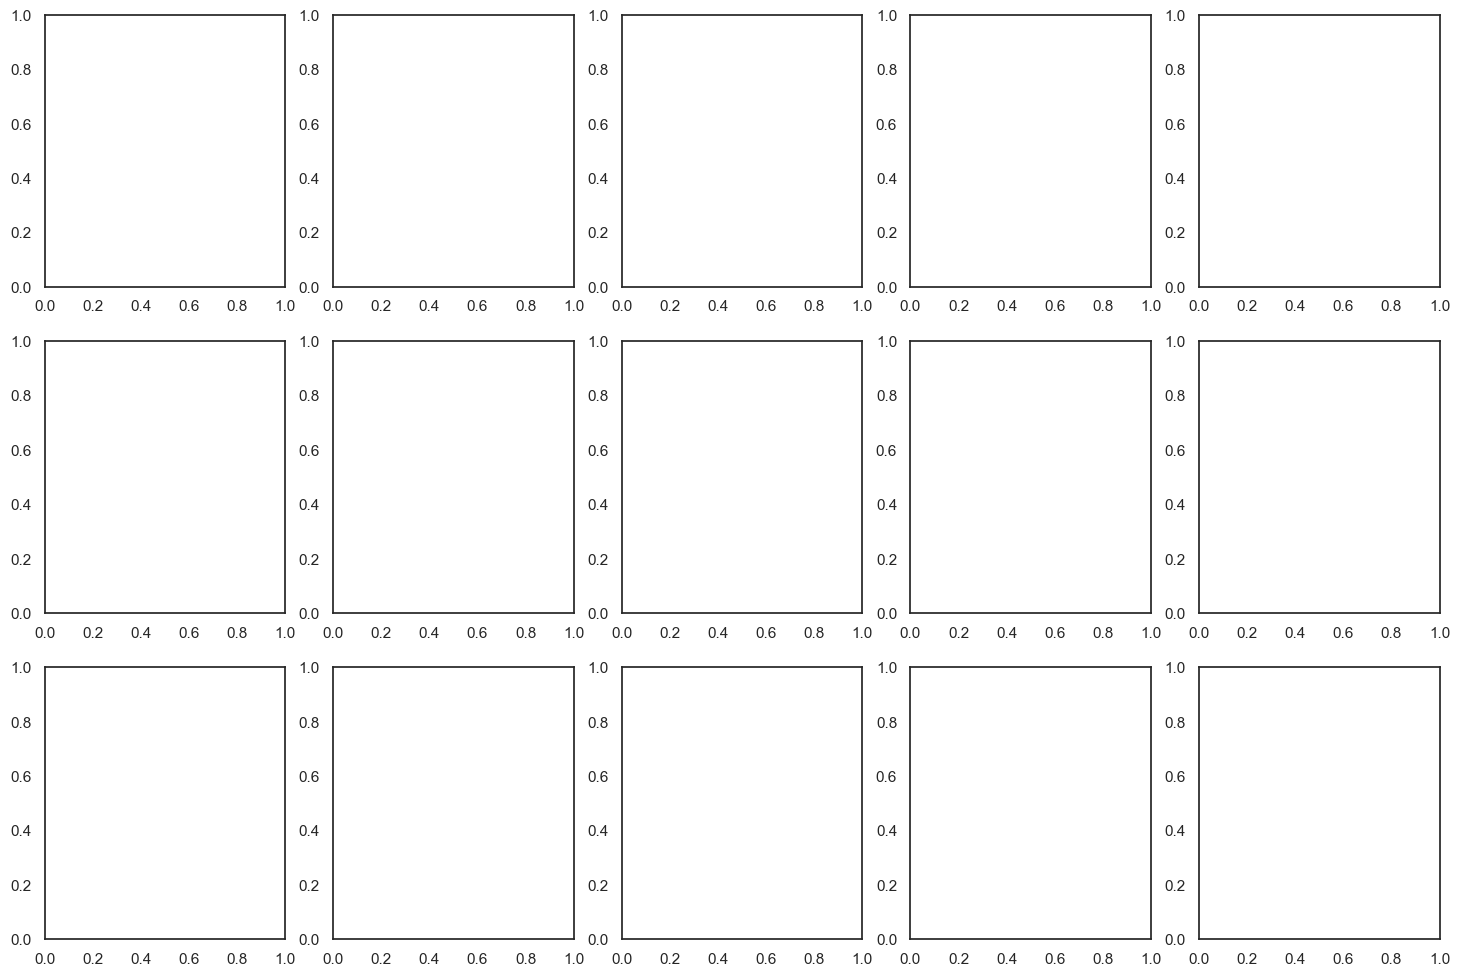

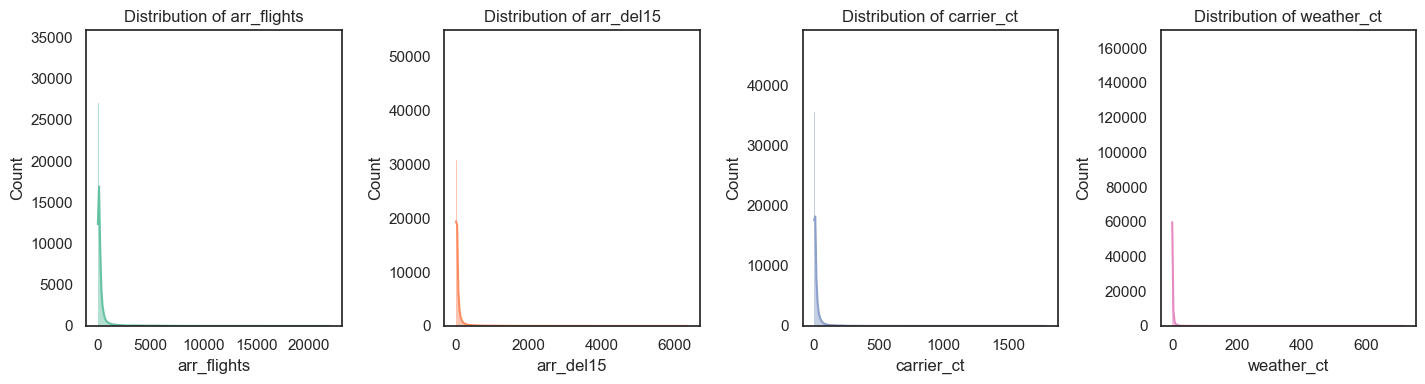

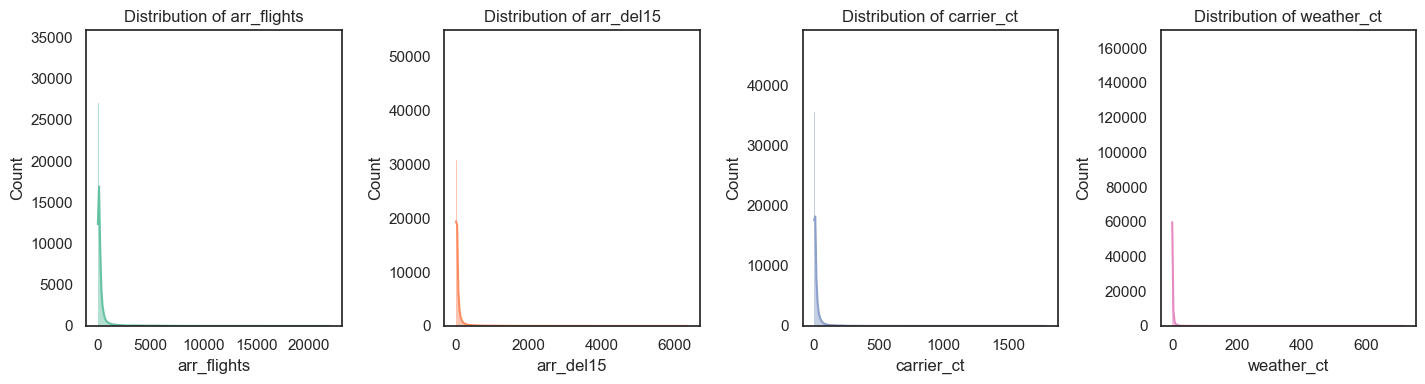

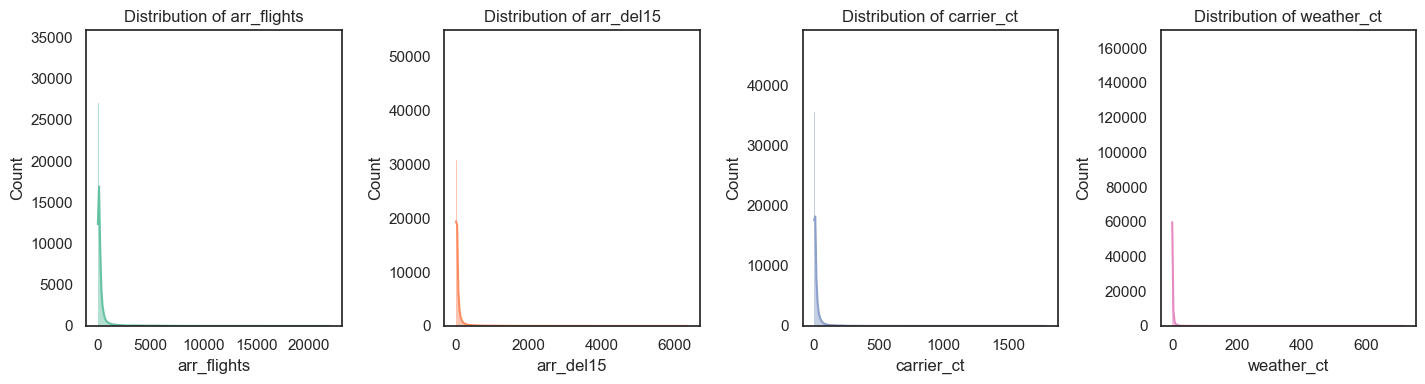

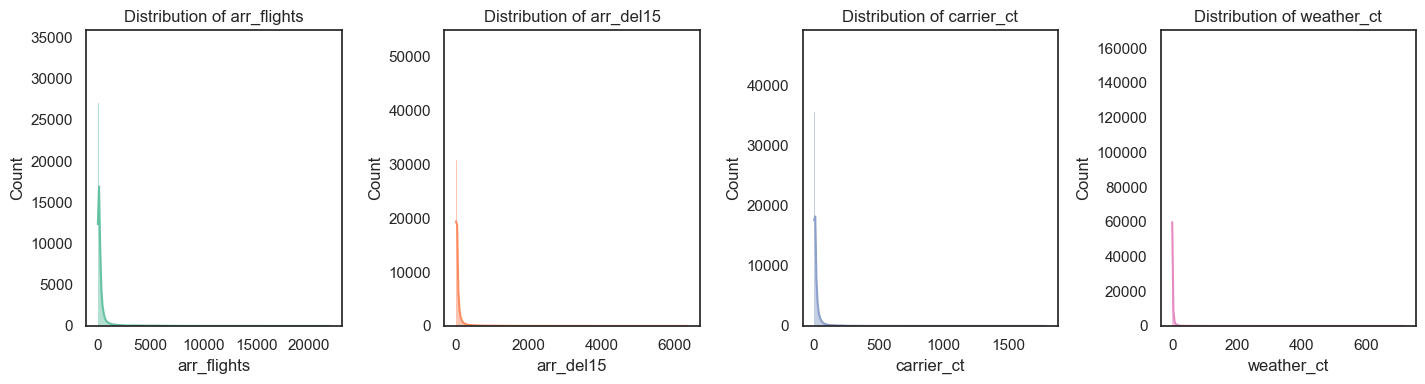

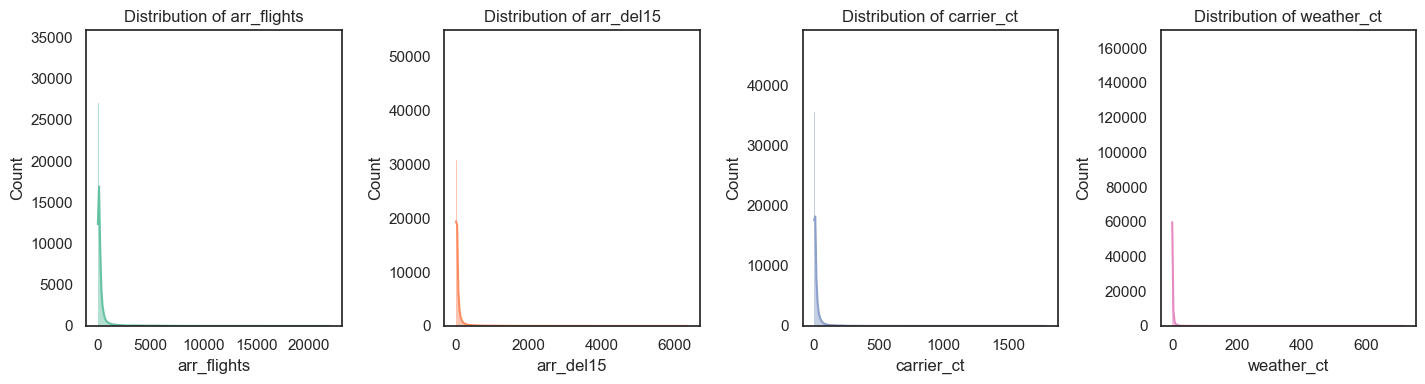

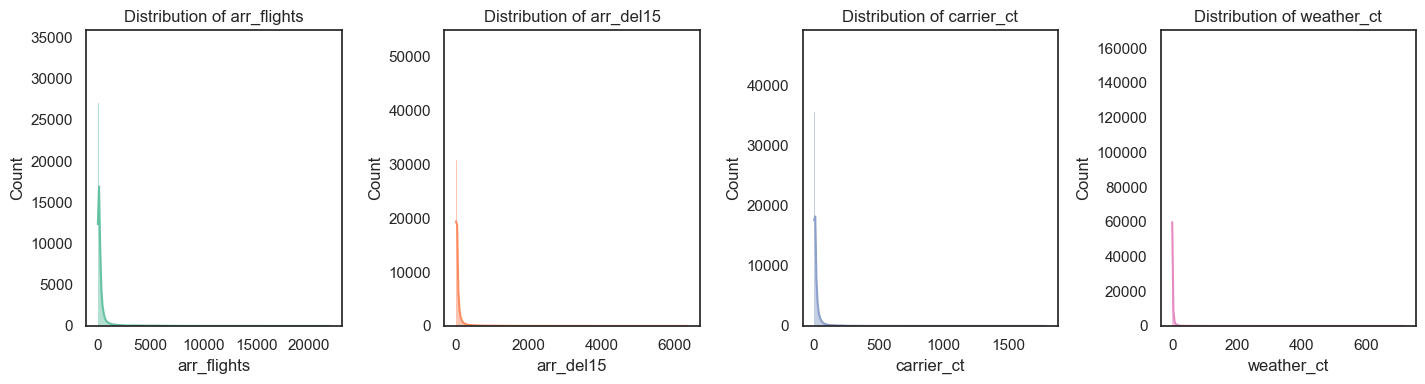

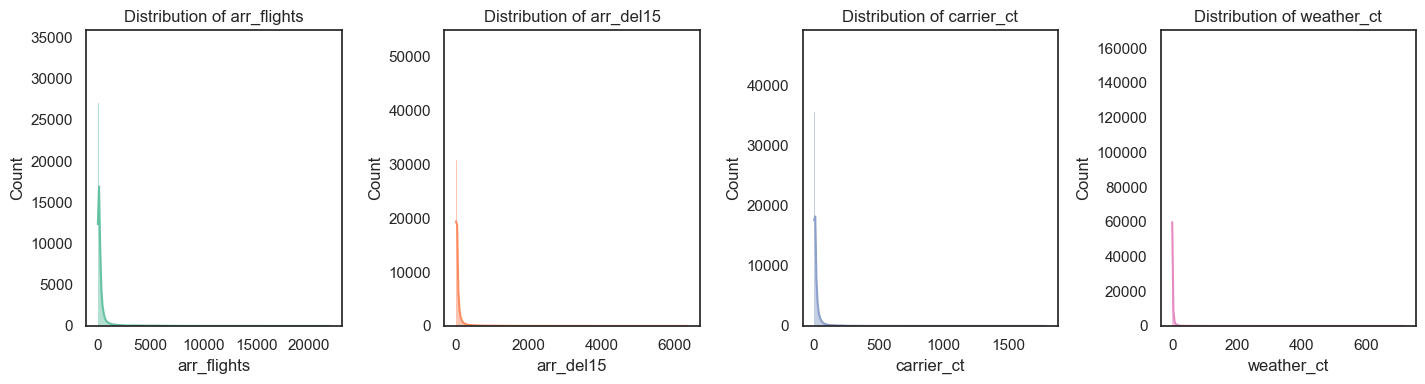

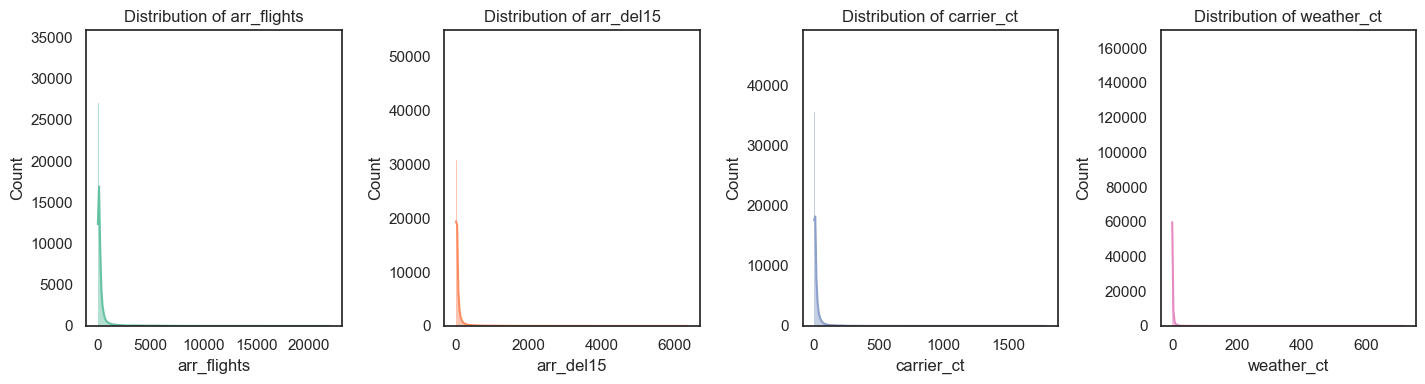

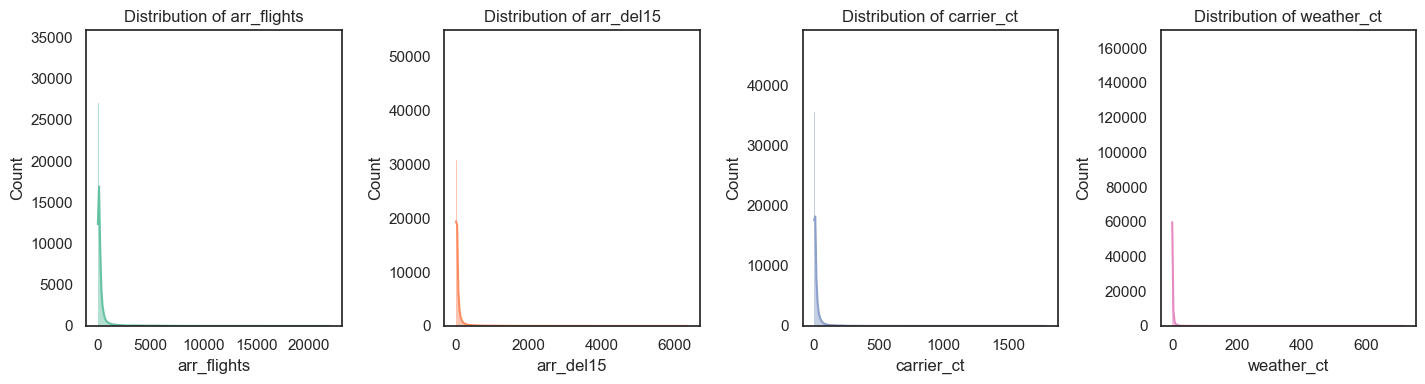

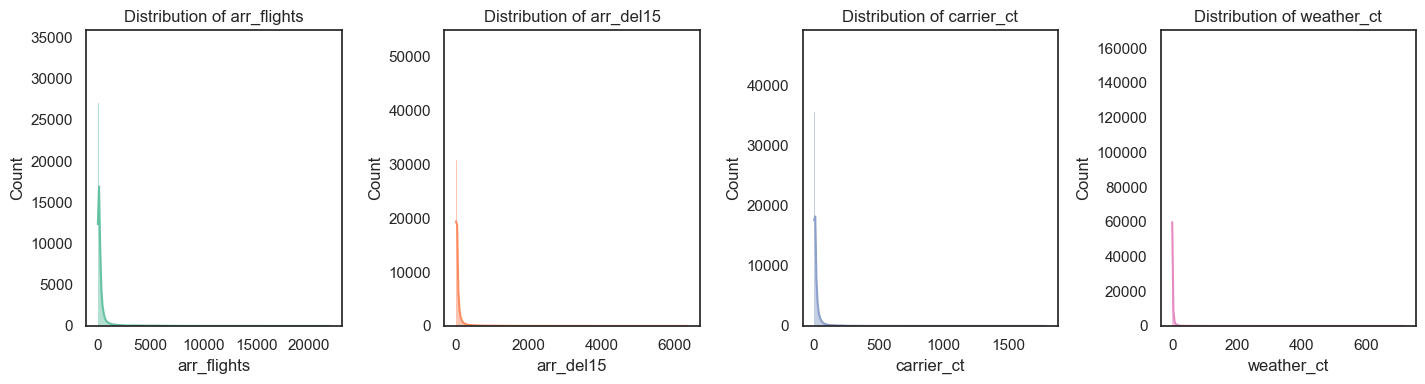

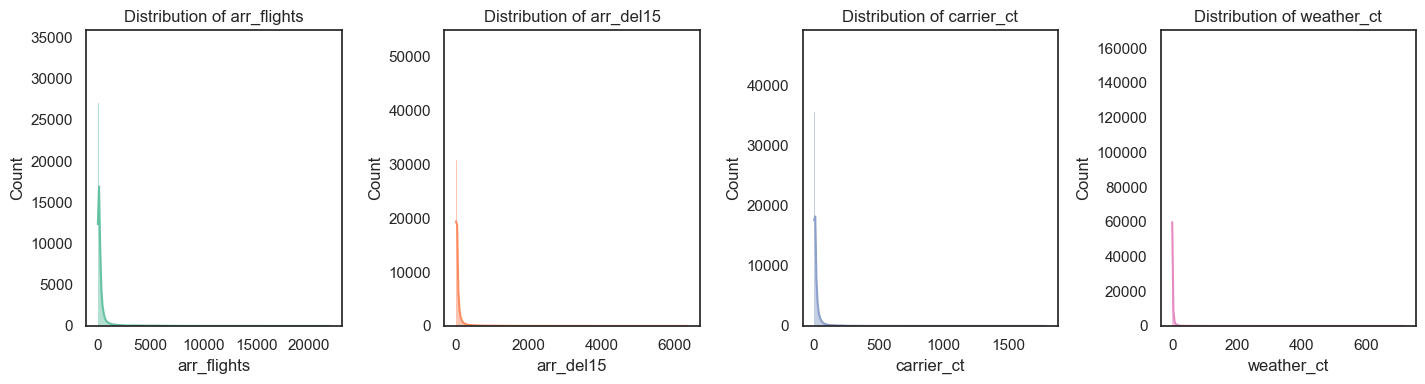

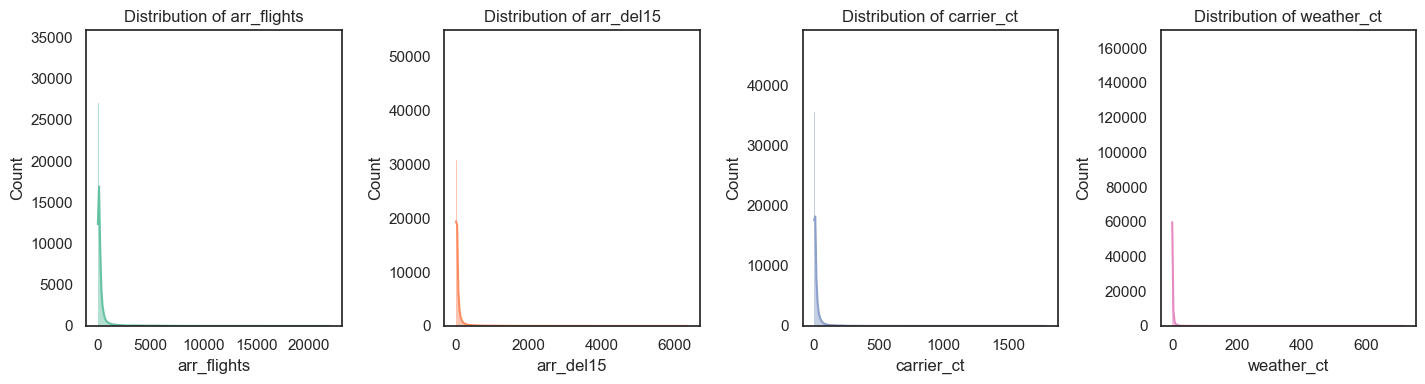

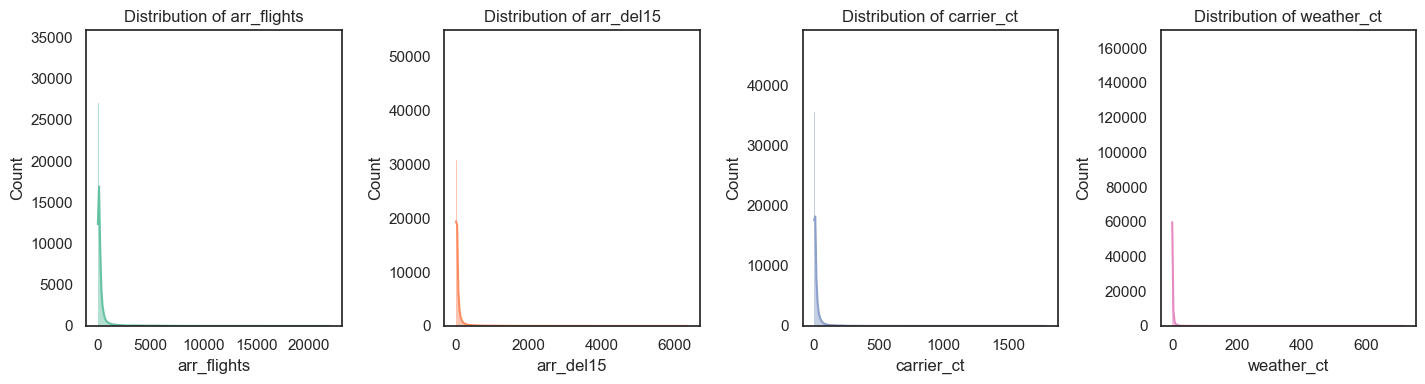

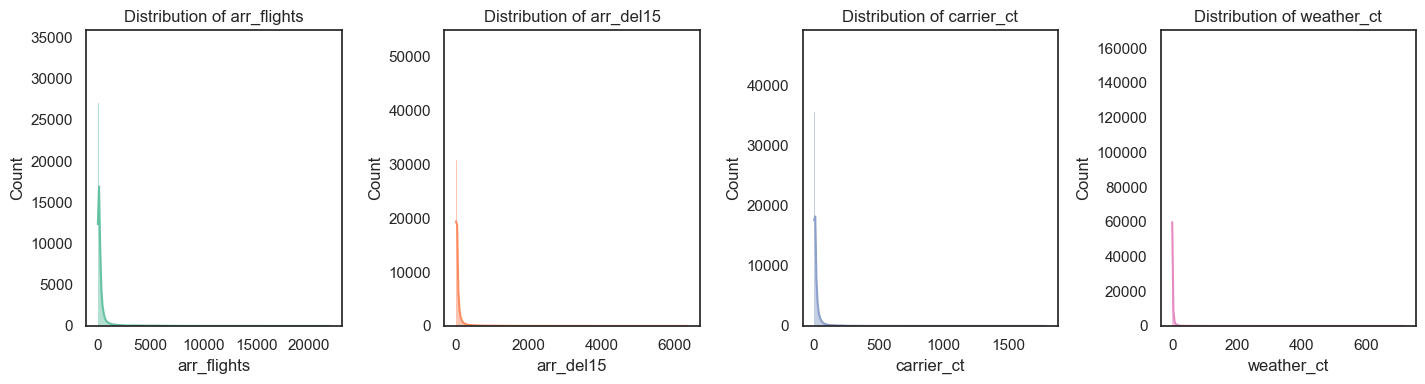

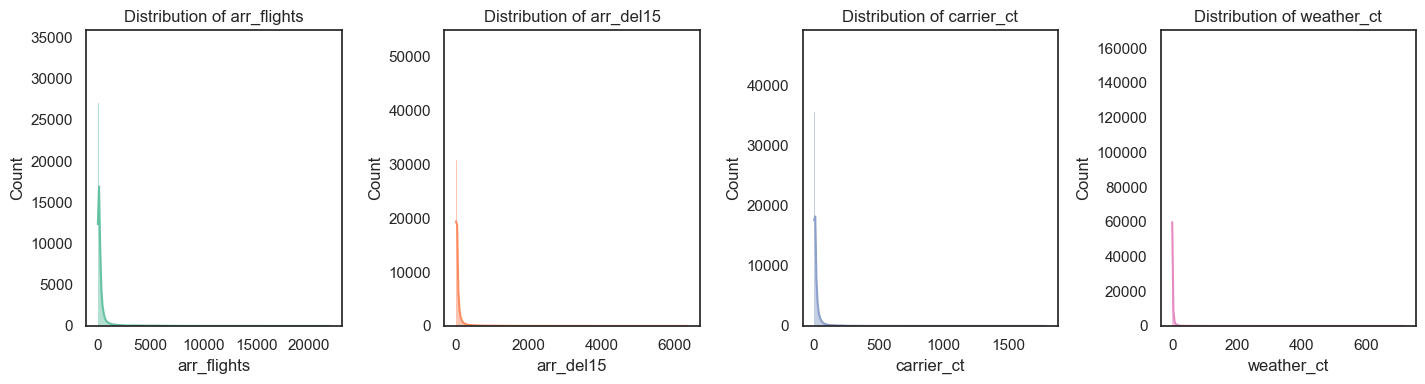

KeyError: <Axes: >

In [33]:
# Distribution of Numeric Features
numeric_features = ['arr_flights', 'arr_del15', 'carrier_ct', 'weather_ct', 'nas_ct',
                    'security_ct', 'late_aircraft_ct', 'arr_cancelled', 'arr_diverted',
                    'arr_delay', 'carrier_delay', 'weather_delay', 'nas_delay',
                    'security_delay', 'late_aircraft_delay']

n_cols = 5
n_rows = int(np.ceil(len(numeric_features) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, feature in enumerate(numeric_features):
    numeric_features = [col for col in ['arr_flights', 'arr_del15', 'carrier_ct', 'weather_ct', 'nas_ct',
                        'security_ct', 'late_aircraft_ct', 'arr_cancelled', 'arr_diverted',
                        'arr_delay', 'carrier_delay', 'weather_delay', 'nas_delay',
                        'security_delay', 'late_aircraft_delay'] if col in data.columns]

    n_cols = 5
    n_rows = int(np.ceil(len(numeric_features) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
    axes = axes.flatten()

    for i, feature in enumerate(numeric_features):
        sns.histplot(data[feature], kde=True, ax=axes[i], color=sns.color_palette('Set2')[i % 8])
        axes[i].set_title(f'Distribution of {feature}')

    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()
    axes[i].set_title(f'Distribution of {feature}')

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

<Figure size 500x500 with 0 Axes>

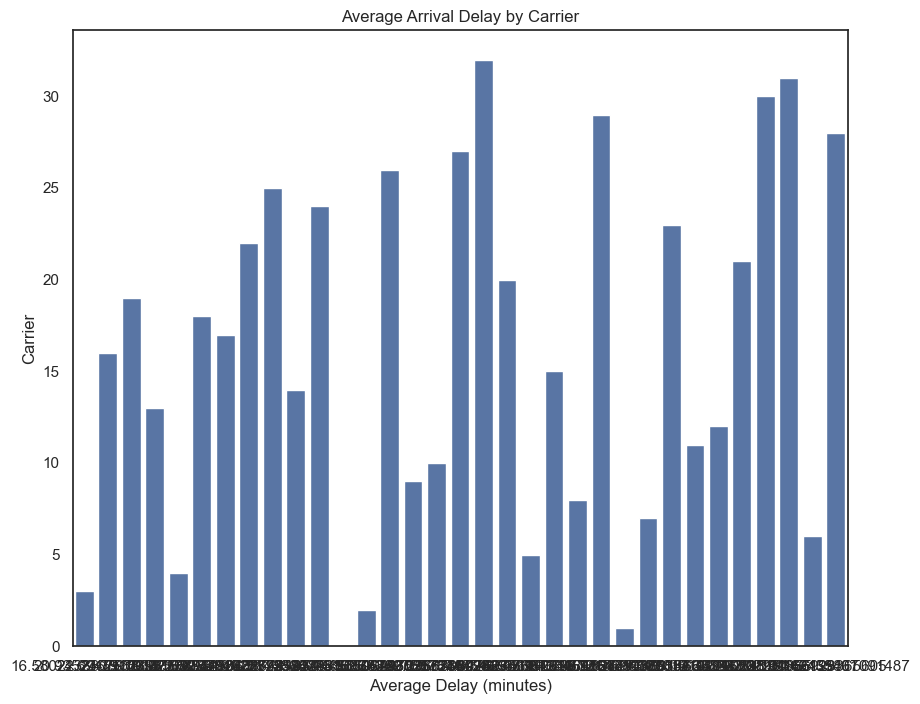

In [32]:
# Performance Analysis Example: Average delay by carrier
plt.figure(figsize=(5,5))
carrier_delay_avg = data.groupby('carrier_name')['arr_del15'].mean().sort_values()
plt.figure(figsize=(10, 8))
sns.barplot(x=carrier_delay_avg, y=carrier_delay_avg.index)
plt.title('Average Arrival Delay by Carrier')
plt.xlabel('Average Delay (minutes)')
plt.ylabel('Carrier')
plt.show()

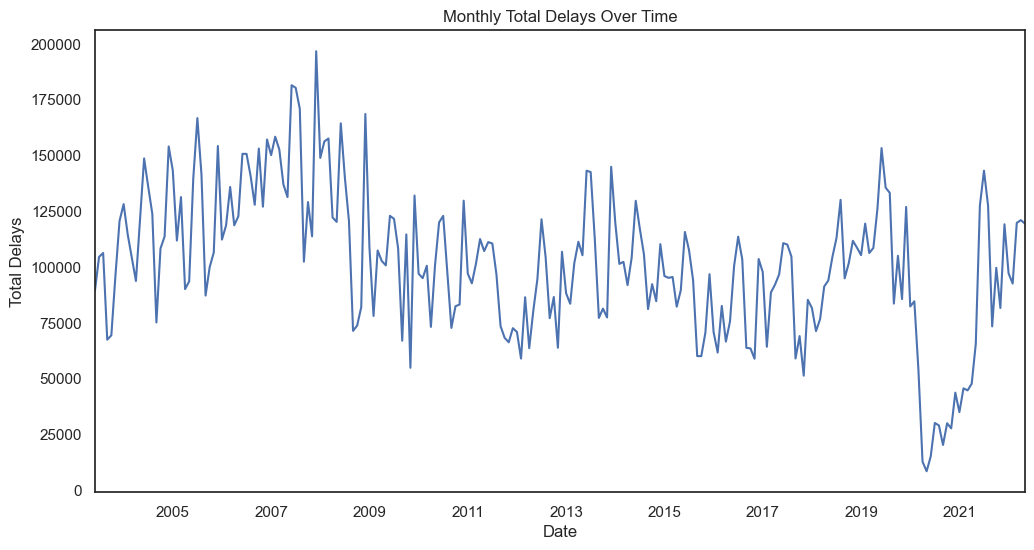

In [13]:
# Trend Identification Example: Total delays over time
data['date'] = pd.to_datetime(data[['year', 'month']].assign(DAY=1))
monthly_delays = data.groupby('date')['arr_del15'].sum()
plt.figure(figsize=(12, 6))
monthly_delays.plot(kind='line')
plt.title('Monthly Total Delays Over Time')
plt.xlabel('Date')
plt.ylabel('Total Delays')
plt.show()

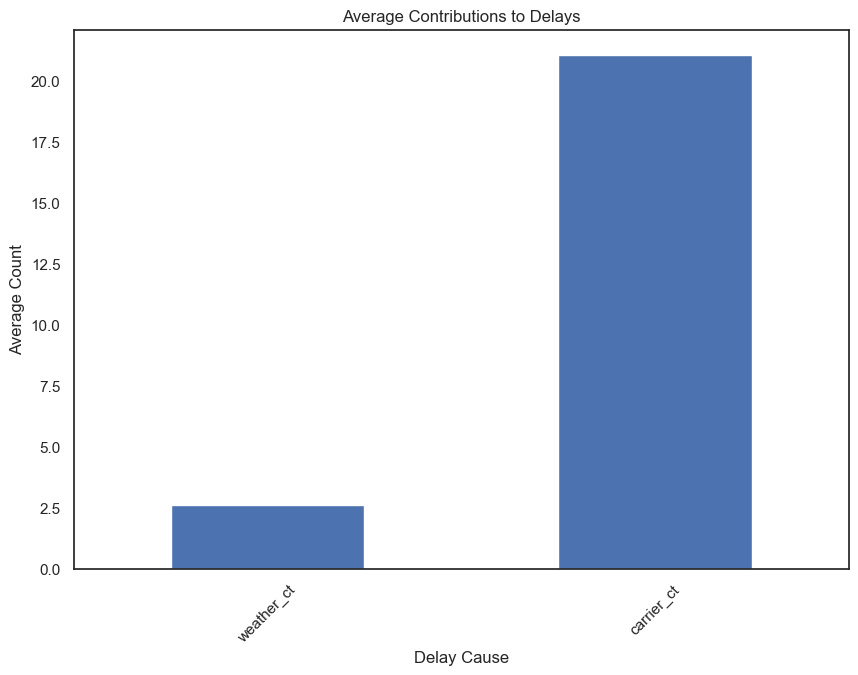

In [31]:
# Root Cause Analysis: Contribution of delay factors
delay_factor_cols = [col for col in ['weather_ct', 'nas_ct', 'security_ct', 'late_aircraft_ct', 'carrier_ct'] if col in data.columns]
delay_factors = data[delay_factor_cols].mean()
delay_factors.plot(kind='bar')
plt.title('Average Contributions to Delays')
plt.xlabel('Delay Cause')
plt.ylabel('Average Count')
plt.xticks(rotation=45)
plt.show()

In [16]:
encoder = LabelEncoder()
for col in cat_cols:
        data[col] = encoder.fit_transform(data[col])

In [17]:
types = data.dtypes
display(types.to_frame(name='Data Types'))

,Data Types
year,int64
month,int64
carrier,int64
carrier_name,int64
airport,int64
airport_name,int64
arr_flights,float64
arr_del15,float64
carrier_ct,float64
weather_ct,float64


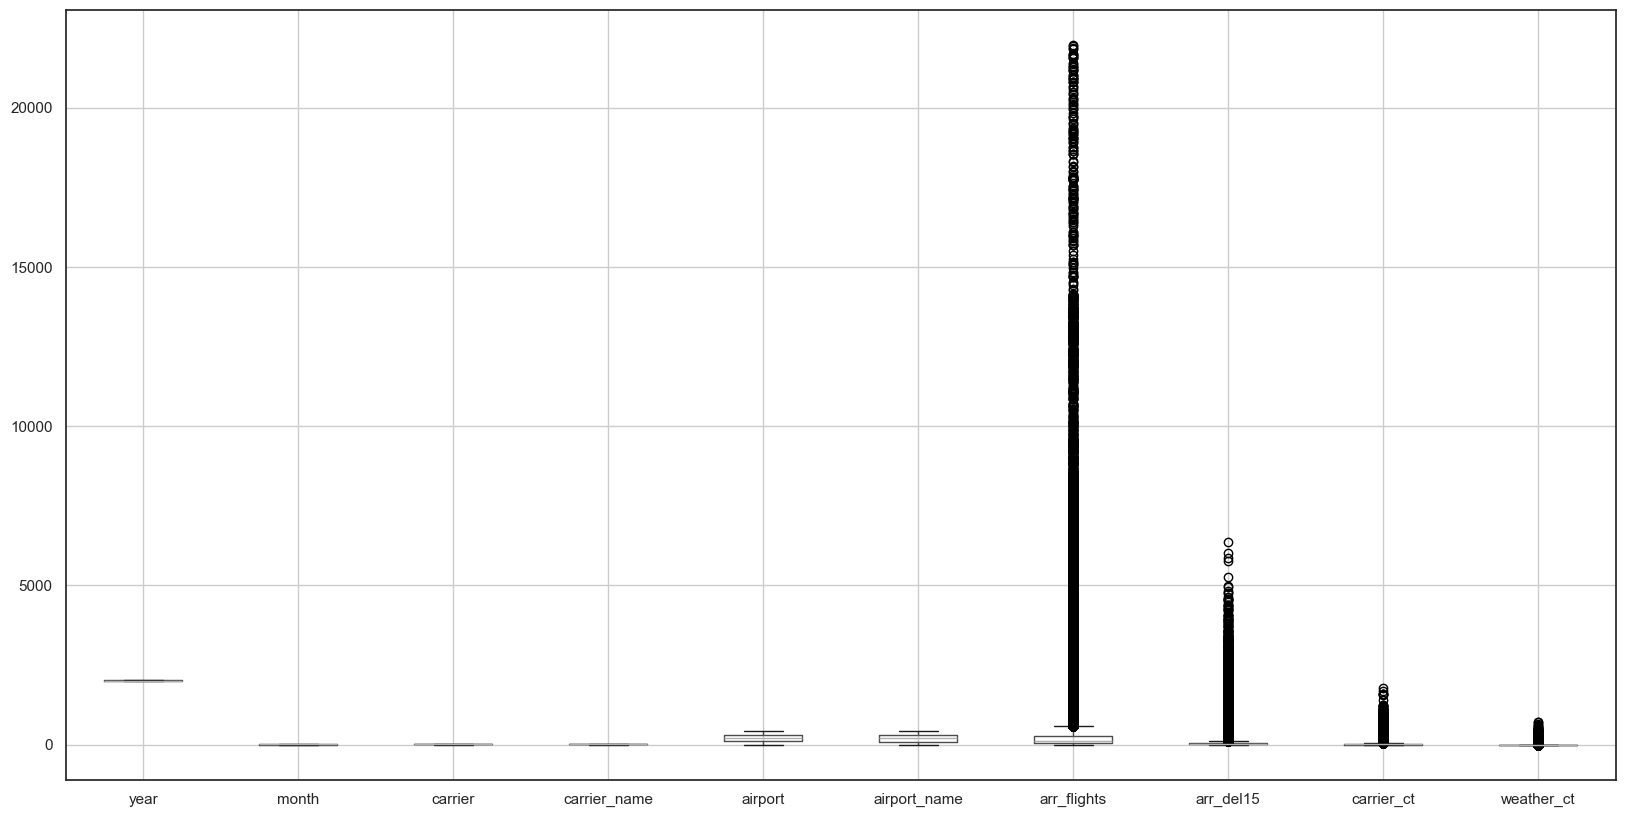

In [18]:
plt.figure(figsize=(20,10))
data.boxplot()
plt.show()

In [30]:
delay_cols = ['arr_delay', 'carrier_delay', 'weather_delay', 'nas_delay', 'security_delay', 'late_aircraft_delay']
delay_cols = [col for col in delay_cols if col in data.columns]

for col in delay_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    data = data[(data[col] >= lower) & (data[col] <= upper)]


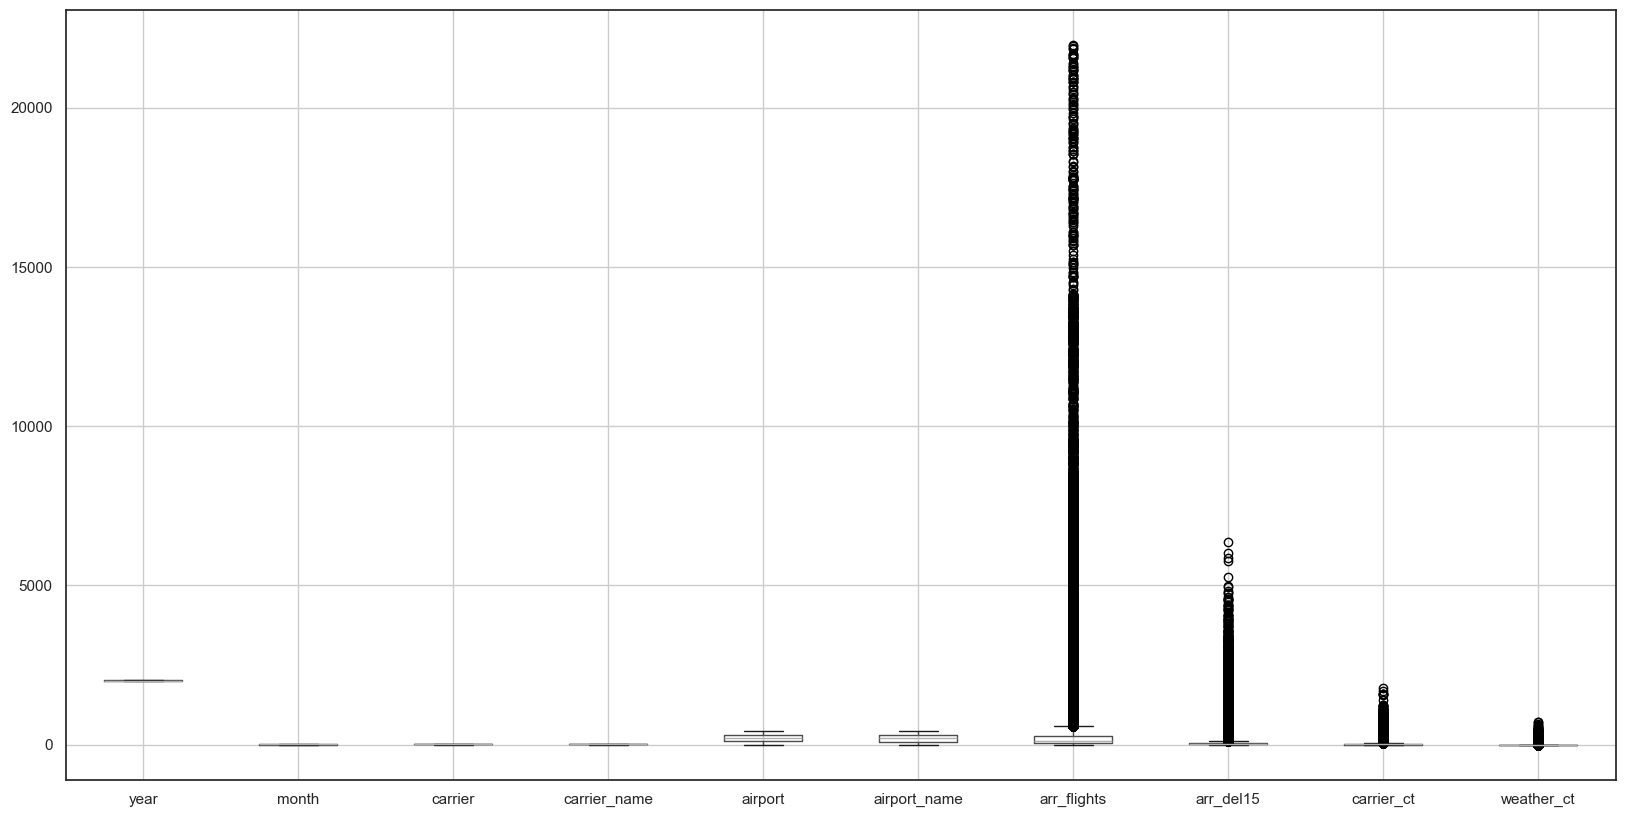

In [20]:
plt.figure(figsize=(20,10))
data.boxplot()
plt.show()

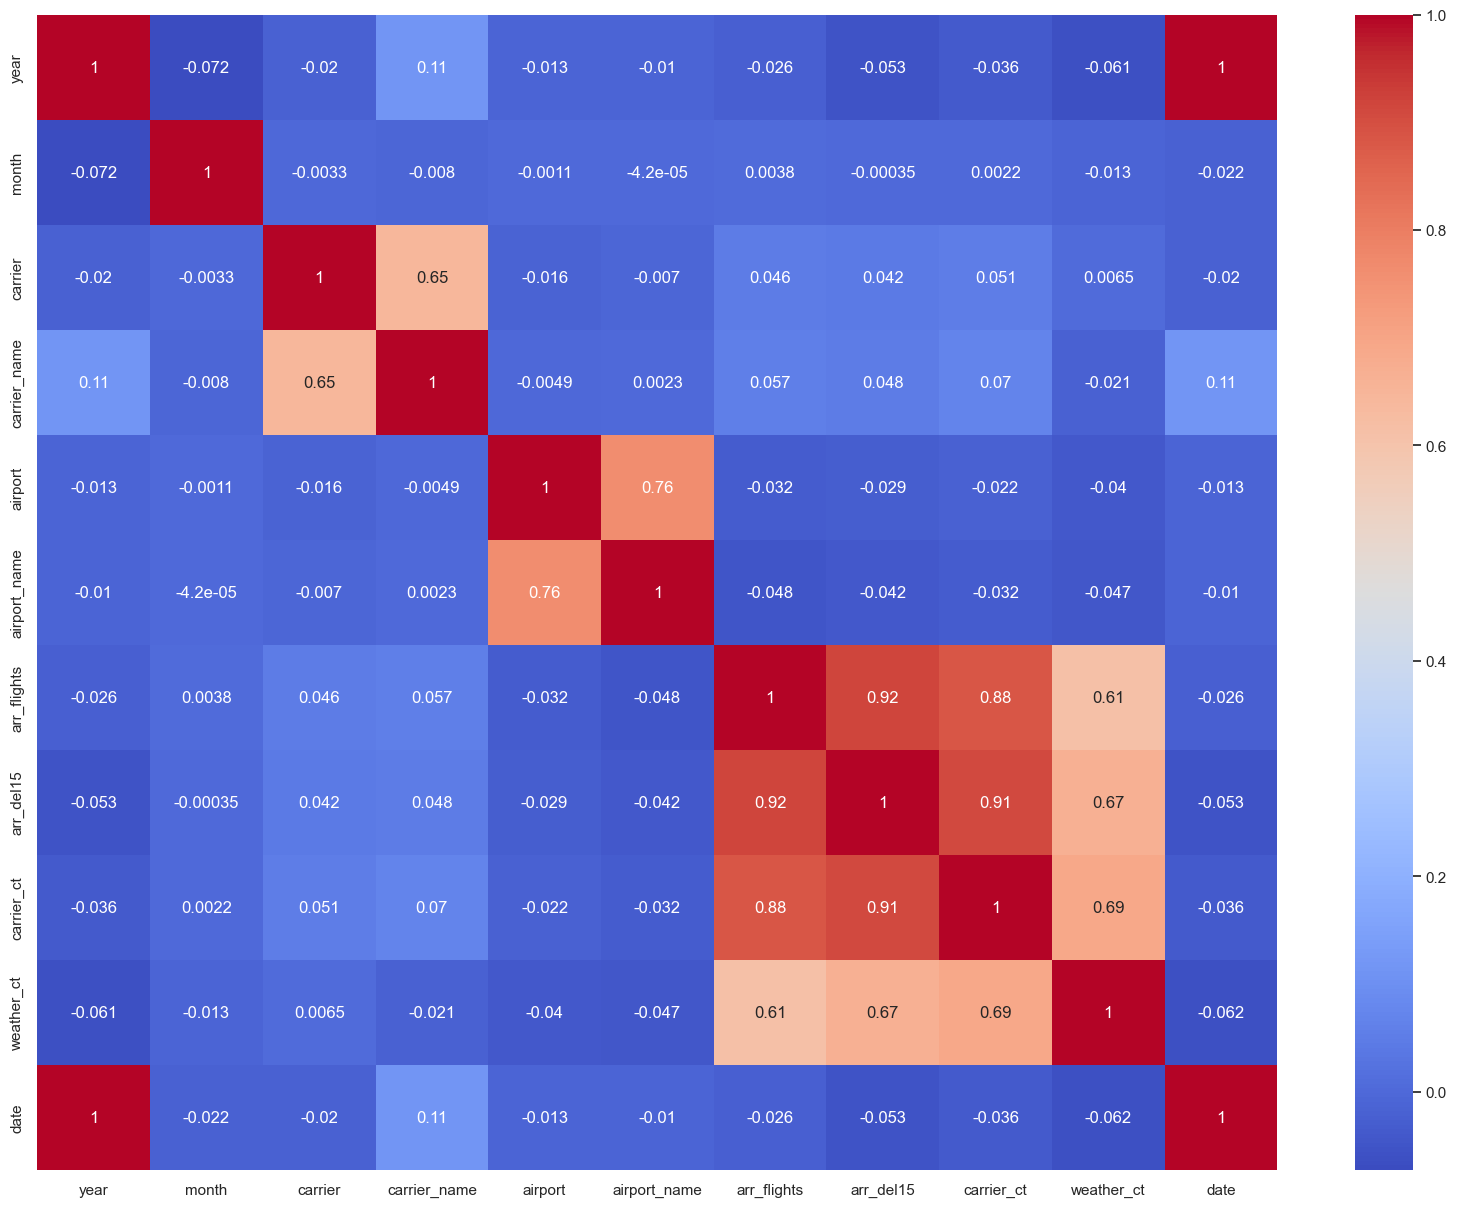

In [21]:
plt.figure(figsize=(20,15))
sns.heatmap(data.corr(), cmap = "coolwarm", annot=True)
plt.show()

In [22]:
# Data Preprocessing for Predictive Modeling
columns_to_drop = ['year', 'month', 'arr_del15']
data_features = data.drop(columns=columns_to_drop)

X = data_features
datetime_columns = X.select_dtypes(include=['datetime64[ns]']).columns
X = X.drop(columns=datetime_columns)

X = X.astype(float)
y = data['arr_del15'] # Target variable

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [23]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape,

((254413, 7), (63604, 7), (254413,), (63604,))

In [24]:
# Linear Regression Model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)
print(f"Linear Regression R^2 Score: {r2_score(y_test, y_pred_lr)}")
print(f"Linear Regression MSE: {mean_squared_error(y_test, y_pred_lr)}")

Linear Regression R^2 Score: 0.8901028816976684
Linear Regression MSE: 4370.75062408536
